# Personal Information
Name: **Christoforos Fragkiadakis**

StudentID: **16229460**

Email: [**christoforos.fragkiadakis@student.uva.nl**](christoforos.fragkiadakis@student.uva.nl)

Submitted on: **22.03.2026**

# Data Context
This thesis utilizes the [DIPSER](https://arxiv.org/abs/2502.20209) dataset, a multimodal dataset designed for analyzing student attention and emotion in real-world, in-person classroom settings. Unlike many existing engagement datasets that are collected in online or controlled environments, DIPSER captures naturalistic classroom behavior, incorporating both visual and physiological signals.

The dataset consists of synchronized RGB image sequences, smartwatch sensor data (e.g., heart rate, accelerometer, gyroscope), and annotated labels for attention and emotion. Data is collected across multiple experimental sessions, including activities such traditional learning (passive learning) and brainstorming (interactive learning). Each student is recorded individually using dedicated cameras and wearable sensors, while additional contextual cameras capture the broader classroom environment. Labels are provided both through self-reporting and multiple expert annotators, enabling the study of subjective and external perceptions of engagement.

For this project due to capacity constraints, only the experiments 2, 3, 5 and 6 are kept for all the groups. These are the descriptions of these experiments according to DIPSER paper:

* Session 2: Brainstorming Session - During this creative session, students generate ideas for projects or solutions to problems.
* Session 3: Lecture - A traditional teaching format where the instructor delivers a lecture in front of the class, with minimal to no student interaction.
* Session 6: Individual Presentation of Work - Students randomly selected present their projects to the group.
* Session 7: Knowledge Test - A formal written assessment on a specific subject area, conducted using
Kahoot to evaluate collective knowledge on the material covered in Session 1.

In [1]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.io as pio
import plotly.express as px
import json

pio.renderers.default = "notebook"
sns.set(style="whitegrid")

### Data Loading

Firstly, the data were downloaded from the official [source](https://www.scidb.cn/en/detail?dataSetId=7856c716c0cc4589a23ee4a23d8a0893#p2). It has to be noted that the whole projects consists of total information of 665 GBs. For this reason, the analysis includes experiments 2,3,5 and 6 from all 3 groups.

As a subsequent step, the .csv files per group/experiment/subject were generated after following the pipeline from the official [repository](https://github.com/luis-marquez/DIPSEER-A-Dataset-for-In-Person-Student-Emotion-and-Engagement-Recognition-in-the-Wild).

In [2]:
df = pd.read_parquet("Data/dipser_transformed_data.parquet", engine="pyarrow")
df.head()

,group,time,subject,experiment,image_path,metadata,labeler_02 emotion,labeler_02 attention,labeler_01 attention,labeler_04 attention,...,samsung_rotation_vector_mean_value2,samsung_rotation_vector_std_value2,samsung_rotation_vector_mean_value3,samsung_rotation_vector_std_value3,opt3007_light_mean,opt3007_light_std,samsung_hr_none_wakeup_sensor_value,gender_name,age,race
0,group01,10:59:49.000776,subject_01,experiment02,/gpfs/work5/0/prjs2039/DIPSER/group01/experime...,/gpfs/work5/0/prjs2039/DIPSER/group01/experime...,9.0,3.0,2.0,3.0,...,0.846155,0.000165,0.493123,0.000083,69.0,0.0,94.0,male,27.0,white
1,group01,10:59:49.147013,subject_01,experiment02,/gpfs/work5/0/prjs2039/DIPSER/group01/experime...,/gpfs/work5/0/prjs2039/DIPSER/group01/experime...,NaN,NaN,NaN,NaN,...,0.846155,0.000165,0.493123,0.000083,69.0,0.0,94.0,male,27.0,white
2,group01,10:59:49.252899,subject_01,experiment02,/gpfs/work5/0/prjs2039/DIPSER/group01/experime...,/gpfs/work5/0/prjs2039/DIPSER/group01/experime...,NaN,NaN,NaN,NaN,...,0.846155,0.000165,0.493123,0.000083,69.0,0.0,94.0,male,27.0,white
3,group01,10:59:49.343618,subject_01,experiment02,/gpfs/work5/0/prjs2039/DIPSER/group01/experime...,/gpfs/work5/0/prjs2039/DIPSER/group01/experime...,NaN,NaN,NaN,NaN,...,0.846155,0.000165,0.493123,0.000083,69.0,0.0,94.0,male,27.0,white
4,group01,10:59:49.504931,subject_01,experiment02,/gpfs/work5/0/prjs2039/DIPSER/group01/experime...,/gpfs/work5/0/prjs2039/DIPSER/group01/experime...,NaN,NaN,NaN,NaN,...,0.846155,0.000165,0.493123,0.000083,69.0,0.0,94.0,male,27.0,white


In [3]:
df.isna().sum()

group                                               0
time                                                0
subject                                             0
experiment                                          0
image_path                                          0
metadata                                            0
labeler_02 emotion                             483797
labeler_02 attention                           486001
labeler_01 attention                           476637
labeler_04 attention                           486057
labeler_04 emotion                             486317
labeler_03 emotion                             482568
labeler_03 attention                           480895
labeler_01 emotion                             485386
self_labeling emotion                          485127
self_labeling attention                        484989
labeler_02 emotionfilled                            0
labeler_02 attentionfilled                          0
labeler_01 attentionfilled  

**Raw label columns (labeler_X attention, emotion)**
* Contain values only when a label changes
* All other rows are NaN
* Represent event-based annotations (change points)

**Filled label columns (_attentionfilled, _emotionfilled)**
* Created using forward fill (ffill)
* Propagate the last known value across frames
* Represent a continuous time-series signal
  
For example if attention = 3 at time t, it stays 3 until the next update.


Regarding Labelers 4 and 5, they did not participate in evaluating all experiments of some groups. For some experiments labeler4 participated, and for some others labeler5. There is no experiment on which both labelers 4 and 5 participated.

### Attention distribution

We examine the distribution of attention labels. This is critical because class imbalance can bias model training and affect fairness across groups.

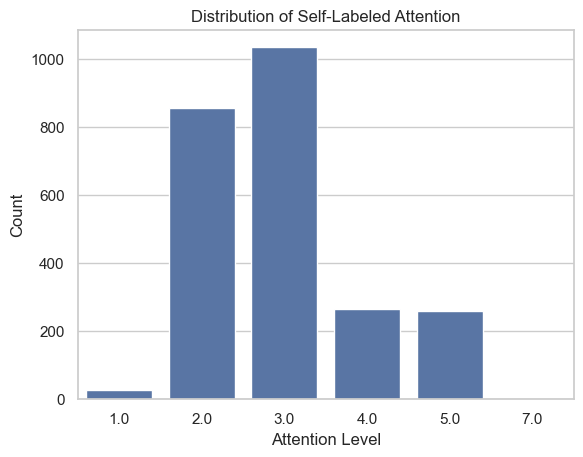

In [5]:
plt.figure()
sns.countplot(x='self_labeling attention', data=df)
plt.title("Distribution of Self-Labeled Attention")
plt.xlabel("Attention Level")
plt.ylabel("Count")
plt.show()

The distribution of self-labeled attention is clearly imbalanced, with the majority of samples concentrated in the mid-range levels (2 and especially 3). Extreme values (1 and 5) are relatively rare.

This suggests that:

Most students are perceived as moderately engaged, rather than clearly disengaged or highly attentive.

The dataset exhibits class imbalance, which may bias models toward predicting the dominant classes (level 2 and 3).

Rare classes (particularly 1 and 5) may be harder to learn, potentially leading to poorer performance and fairness issues for underrepresented engagement states.

This imbalance should be taken into account during modeling, for example through re-weighting or balanced evaluation metrics.

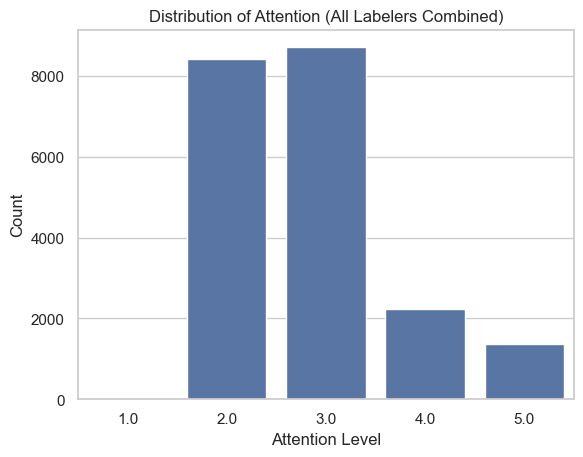

In [91]:
labeler_cols = [
    'labeler_01 attention',
    'labeler_02 attention',
    'labeler_03 attention',
    'labeler_04 attention',
    'labeler_05 attention'
]

df_long = df.melt(
    value_vars=labeler_cols,
    var_name='labeler',
    value_name='attention'
)

plt.figure()
sns.countplot(x='attention', data=df_long)
plt.title("Distribution of Attention (All Labelers Combined)")
plt.xlabel("Attention Level")
plt.ylabel("Count")
plt.show()

### Emotion Distribution

We analyze the distribution of emotional states. In this thesis we aim to predict the attention label, but knowing the emotion distribution is also useful since it will be used as a feature to our target variable

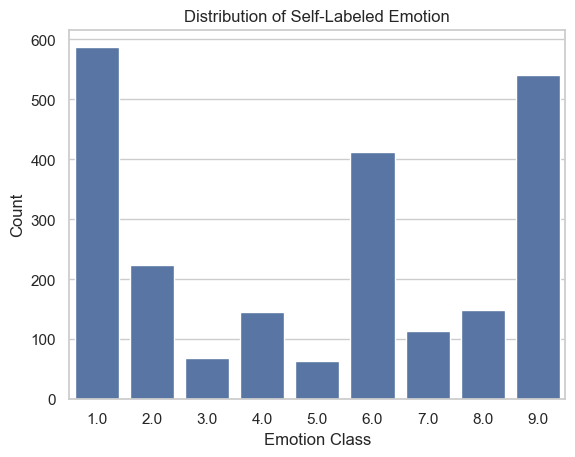

In [6]:
plt.figure()
sns.countplot(x='self_labeling emotion', data=df)
plt.title("Distribution of Self-Labeled Emotion")
plt.xlabel("Emotion Class")
plt.ylabel("Count")
plt.show()

According to DIPSER paper: "Emotion is categorized into nine categories: 9: Enjoyment, 8: Hope, 7: Pride, 6: Relief, 5: Anger, 4:
Anxiety, 3: Shame, 2: Despair, 1: Boredom."

The distribution of self-labeled emotions is highly imbalanced, with a strong dominance of a few classes. In particular, Boredom (1) and Enjoyment (9) appear most frequently, followed by Relief (6), while several emotions such as Anger (5) and Shame (3) are relatively rare.

This indicates that the dataset is skewed toward low-arousal (e.g., boredom) and positive emotions (e.g., enjoyment, relief), while more intense or negative emotional states are underrepresented.

### Average Attention per experiment

In [14]:
df.columns

Index(['group', 'time', 'subject', 'experiment', 'image_path', 'metadata',
       'labeler_02 emotion', 'labeler_02 attention', 'labeler_01 attention',
       'labeler_04 attention', 'labeler_04 emotion', 'labeler_03 emotion',
       'labeler_03 attention', 'labeler_01 emotion', 'self_labeling emotion',
       'self_labeling attention', 'labeler_02 emotionfilled',
       'labeler_02 attentionfilled', 'labeler_01 attentionfilled',
       'labeler_04 attentionfilled', 'labeler_04 emotionfilled',
       'labeler_03 emotionfilled', 'labeler_03 attentionfilled',
       'labeler_01 emotionfilled', 'self_labeling emotionfilled',
       'self_labeling attentionfilled', 'labeler_05 emotion',
       'labeler_05 attention', 'labeler_05 emotionfilled',
       'labeler_05 attentionfilled', 'lsm6dso_gyroscope_mean_x',
       'lsm6dso_gyroscope_std_x', 'lsm6dso_gyroscope_mean_y',
       'lsm6dso_gyroscope_std_y', 'lsm6dso_gyroscope_mean_z',
       'lsm6dso_gyroscope_std_z', 'lsm6dso_gyroscope_mean_ma

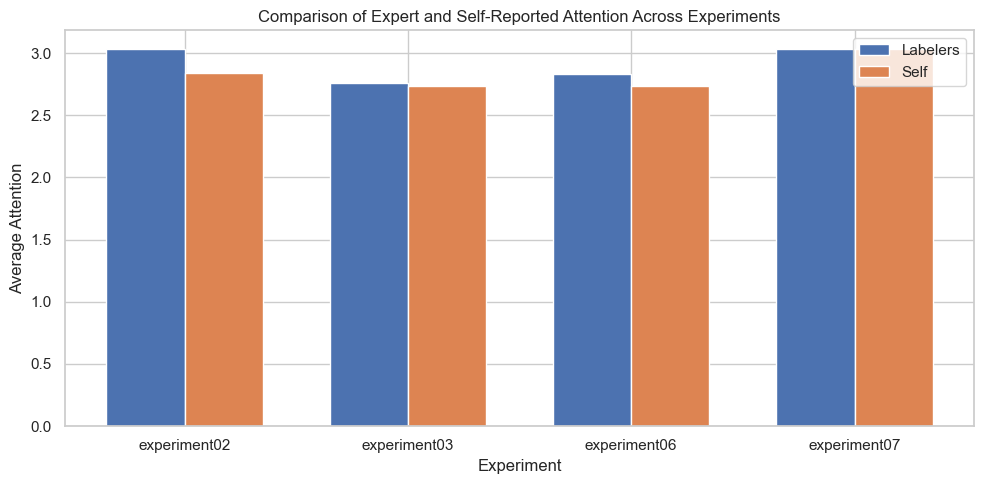

In [24]:
labeler_attention_cols = [
    col for col in df.columns
    if 'attentionfilled' in col and 'self' not in col
]

df['labeler_mean_attention'] = df[labeler_attention_cols].mean(axis=1)
# df['labeler_mean_attention'] = round(df['labeler_mean_attention'])
comparison = (
    df
    .groupby('experiment')[['labeler_mean_attention', 'self_labeling attentionfilled']]
    .mean()
    .reset_index()
)


x = comparison['experiment']
x_pos = np.arange(len(x))
width = 0.35

plt.figure(figsize=(10,5))

plt.bar(x_pos - width/2, comparison['labeler_mean_attention'], 
        width=width, label='Labelers')

plt.bar(x_pos + width/2, comparison['self_labeling attentionfilled'], 
        width=width, label='Self')

plt.xlabel("Experiment")
plt.ylabel("Average Attention")
plt.title("Comparison of Expert and Self-Reported Attention Across Experiments")
plt.legend()

plt.xticks(x_pos, x, rotation=0)
plt.tight_layout()
plt.show()

In [25]:
comparison

,experiment,labeler_mean_attention,self_labeling attentionfilled
0,experiment02,3.030299,2.839034
1,experiment03,2.760466,2.735817
2,experiment06,2.829036,2.735428
3,experiment07,3.029517,3.029727


The bar chart compares average attention levels between expert annotators and self-reported measures across experiments. Overall, both signals exhibit similar trends, with attention values consistently ranging between approximately 2.7 and 3.0. In most experiments, expert and self-assessments are closely aligned, indicating general agreement in perceived engagement.

According to labelers, experiment 2 had the highest attention levels.

Recalling the description of each experiment according to DIPSER:

* Session 2: Brainstorming Session - During this creative session, students generate ideas for projects or solutions to problems.
* Session 3: Lecture - A traditional teaching format where the instructor delivers a lecture in front of the class, with minimal to no student interaction.
* Session 6: Individual Presentation of Work - Students randomly selected present their projects to the group.
* Session 7: Knowledge Test - A formal written assessment on a specific subject area, conducted using
Kahoot to evaluate collective knowledge on the material covered in Session 1.

Experiment 2 and 7 seem to have very close attention levels, with experiments 3 and 6 appearing to be 10% lower.

### Average Attention per experiment and subject according to labellers

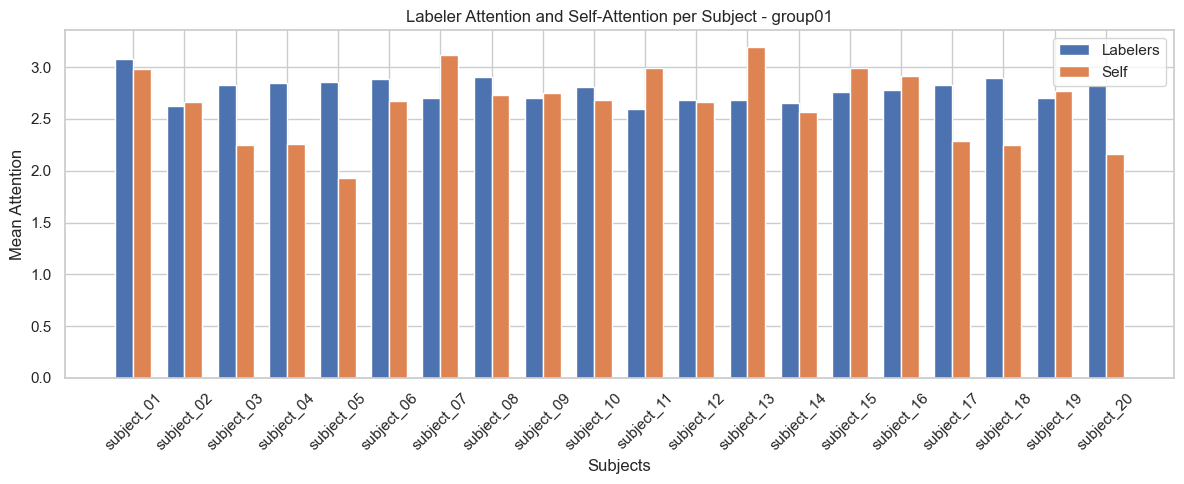

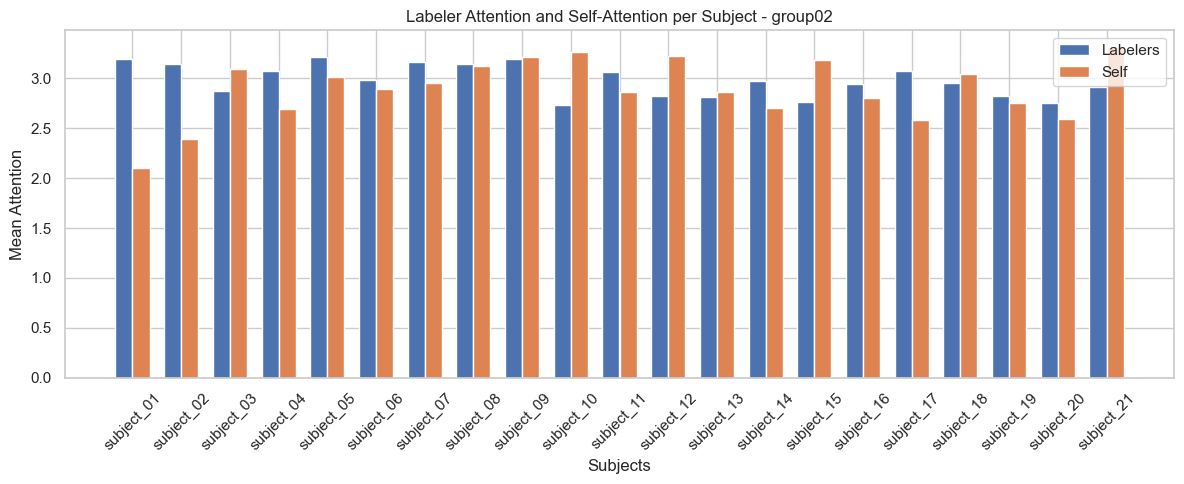

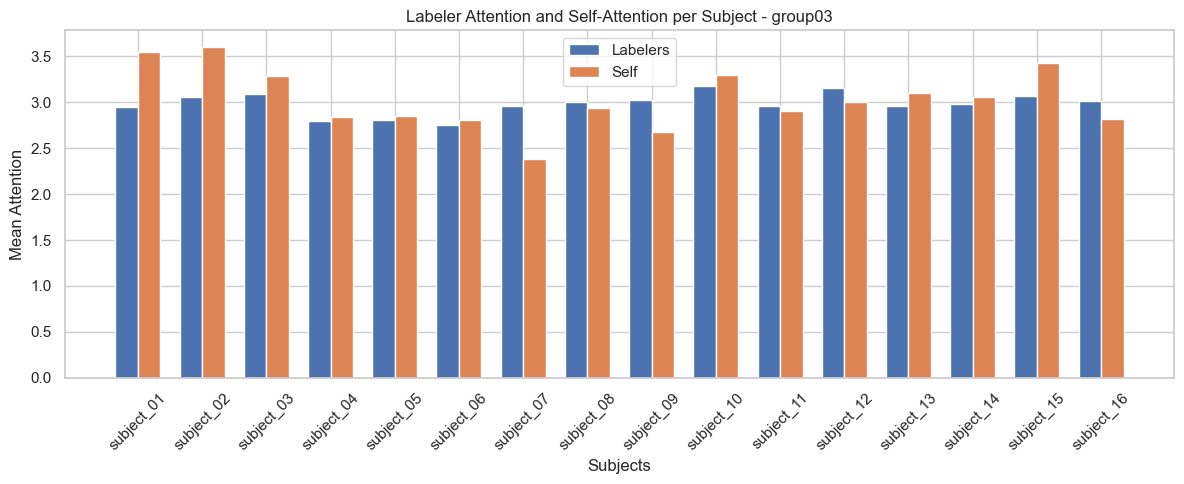

In [28]:
group_subject_attention = (
    df
    .groupby(['group', 'subject'])
    .agg({
        'labeler_mean_attention': 'mean',
        'self_labeling attentionfilled': 'mean'
    })
    .reset_index()
)
groups = group_subject_attention['group'].unique()

for g in groups:
    data = group_subject_attention[group_subject_attention['group'] == g]
    
    x = np.arange(len(data))
    width = 0.35

    plt.figure(figsize=(12,5))
    
    plt.bar(x - width/2, data['labeler_mean_attention'], 
            width=width, label='Labelers')
    
    plt.bar(x + width/2, data['self_labeling attentionfilled'], 
            width=width, label='Self')

    plt.title(f"Labeler Attention and Self-Attention per Subject - {g}")
    plt.xlabel("Subjects")
    plt.ylabel("Mean Attention")
    
    plt.xticks(x, data['subject'], rotation=45)
    plt.legend()
    
    plt.tight_layout()
    plt.show()

The bar charts comparing mean labeler attention and self-reported attention per subject across the three groups reveal generally consistent but nuanced patterns of agreement and divergence between external and internal assessments of engagement. Across all groups, most subjects exhibit mean attention values within the mid-to-high range (approximately 2.5 to 3.2), indicating overall moderate engagement levels, which aligns with the expected variability of attention across different classroom activities in DIPSER .

In group01, labeler attention tends to be slightly higher and more stable than self-reported attention, with several subjects (e.g., subject_04, subject_05, subject_20) showing noticeably lower self-perception. This suggests a tendency for some students to underestimate their own engagement, or reflects differences in observable vs internal attention cues.

In group02, the alignment between labelers and self-reports is stronger overall, with many subjects showing nearly identical scores. However, a few discrepancies remain (e.g., subject_01 and subject_12), indicating that even in more consistent groups, subjective perception of attention can deviate from expert evaluation.

In group03, self-reported attention is often equal to or higher than labeler scores for several subjects (e.g., subject_01, subject_02, subject_15), suggesting a shift toward overestimation of engagement. This group also exhibits slightly tighter clustering, indicating more homogeneous engagement patterns.

Overall, while there is moderate agreement between labeler and self-attention, systematic biases emerge across groups, ranging from underestimation to overestimation, highlighting the importance of combining both perspectives when modeling engagement. These discrepancies are particularly relevant for fairness-aware modeling, as they may reflect differences in self-perception, expressiveness, or annotation subjectivity across individuals.

In [84]:
df['attention_diff'] = df['self_labeling attentionfilled'] - df['labeler_mean_attention']
df['subject_id'] = df['group'].astype(str) + "_" + df['subject'].astype(str)

subject_diff = (
    df
    .groupby(['subject_id', 'group',  'subject', 'gender_name'])
    .agg({
        'attention_diff': 'mean'
    })
    .reset_index()
)

threshold = 0.5

underestimated = subject_diff[subject_diff['attention_diff'] < -threshold]
overestimated  = subject_diff[subject_diff['attention_diff'] > threshold]

print("Underestimated subjects:", underestimated['subject_id'].nunique())
print("Overestimated subjects:", overestimated['subject_id'].nunique())

print("\nUnderestimated gender distribution:")
print(underestimated['gender_name'].value_counts(normalize=True))

print("\nOverestimated gender distribution:")
print(overestimated['gender_name'].value_counts(normalize=True))


print("\n Gender distribution:")
print(subject_diff['gender_name'].value_counts(normalize=True))

Underestimated subjects: 9
Overestimated subjects: 4

Underestimated gender distribution:
gender_name
male      0.555556
female    0.444444
Name: proportion, dtype: float64

Overestimated gender distribution:
gender_name
female    0.75
male      0.25
Name: proportion, dtype: float64

 Gender distribution:
gender_name
female    0.684211
male      0.315789
Name: proportion, dtype: float64


Interpretation A (bias in labelers):
Labelers overestimate females
Labelers underestimate males

Interpretation B (bias in self-perception):
Males rate themselves lower
Females rate themselves higher

In [85]:
subject_diff

,subject_id,group,subject,gender_name,attention_diff
0,group01_subject_01,group01,subject_01,male,-0.089675
1,group01_subject_02,group01,subject_02,female,0.039964
2,group01_subject_03,group01,subject_03,male,-0.575073
3,group01_subject_04,group01,subject_04,male,-0.585734
4,group01_subject_05,group01,subject_05,female,-0.932626
5,group01_subject_06,group01,subject_06,female,-0.216438
6,group01_subject_07,group01,subject_07,male,0.417697
7,group01_subject_08,group01,subject_08,male,-0.173795
8,group01_subject_09,group01,subject_09,male,0.042993
9,group01_subject_10,group01,subject_10,female,-0.121030


In [81]:
subject_diff.groupby('gender_name')['attention_diff'].mean()

gender_name
female   -0.030168
male     -0.168066
Name: attention_diff, dtype: float64

## TODO:

find on how many subjects we see a deviation of > 10%

and find the gender of them

In [29]:
subject_stats = df.groupby(['group', 'subject'])['self_labeling attention'].agg(['mean', 'std']).reset_index()
subject_stats["text"] = subject_stats['group'] + subject_stats['subject']

fig = px.scatter(
    subject_stats,
    x='mean',
    y='std',
    hover_name='text',
    title="Subject Self-Attention across experiments: Mean and Variability",
    labels={
        'mean': 'Mean Self-Attention',
        'std': 'Std (Variability)'
    }
)

fig.update_traces(textposition='top center')

fig.show()

The scatter plot of mean versus standard deviation of self-reported attention per subject reveals moderate variability in engagement across individuals. Most subjects cluster within a mean attention range of approximately 2.5 to 3.2, indicating generally medium levels of perceived attention. Variability tends to increase slightly with higher mean attention, suggesting that more engaged students may also exhibit greater fluctuations over time. A few outliers are observed, including subjects with very low variability (constant attention, group02 subject 21) and others with higher instability (group01 subject12).

In [30]:
subject_stats_labelers = df.groupby(['group', 'subject'])['labeler_mean_attention'].agg(['mean', 'std']).reset_index()
subject_stats_labelers["text"] = subject_stats_labelers['group'] + subject_stats_labelers['subject']

fig = px.scatter(
    subject_stats_labelers,
    x='mean',
    y='std',
    hover_name='text',
    title="Subject Labeler-Attention across experiments: Mean and Variability",
    labels={
        'mean': 'Mean Labeler Attention',
        'std': 'Std (Variability)'
    }
)

fig.update_traces(textposition='top center')

fig.show()

The scatter plot of mean versus standard deviation of annotator-derived attention per subject shows a relatively tight distribution, indicating consistent labeling across individuals. Most subjects cluster within a mean attention range of approximately 2.7 to 3.1, suggesting moderate to high perceived engagement from external observers. Variability remains generally low, with standard deviation values mostly between 0.5 and 0.7, implying stable annotations over time. Compared to self-reported attention, the annotator-based signal appears more concentrated and less noisy, reflecting a more uniform assessment of engagement across subjects, with only a few mild outliers exhibiting higher variability.

### Metadata analysis

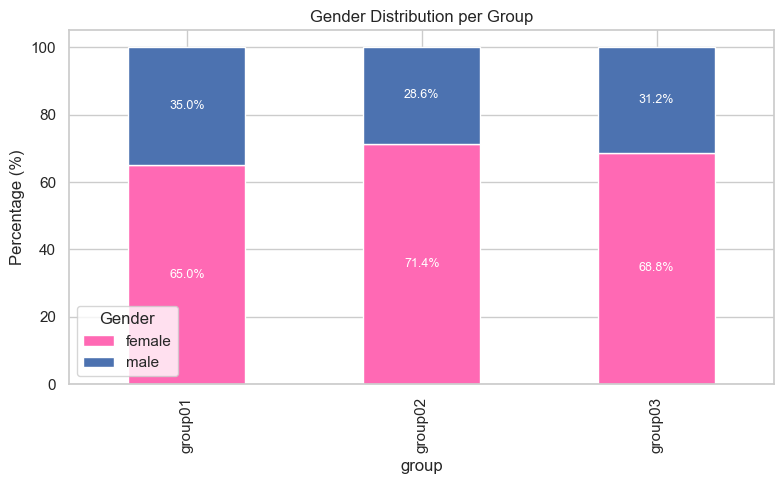

In [16]:
df_unique = df.drop_duplicates(subset=["group", "subject"])

gender_dist = (
    df_unique.groupby(["group", "gender_name"])
    .size()
    .unstack(fill_value=0)
)

gender_pct = gender_dist.div(gender_dist.sum(axis=1), axis=0) * 100

colors = {
    "male": "#4C72B0",     # blue
    "female": "#FF69B4"    # pink
}

fig, ax = plt.subplots(figsize=(8,5))

gender_pct.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    color=[colors.get(col, "gray") for col in gender_pct.columns]
)

ax.set_ylabel("Percentage (%)")
ax.set_title("Gender Distribution per Group")
ax.legend(title="Gender")

for i, group in enumerate(gender_pct.index):
    cumulative = 0
    for gender in gender_pct.columns:
        value = gender_pct.loc[group, gender]
        if value > 5:
            ax.text(
                i,
                cumulative + value / 2,
                f"{value:.1f}%",
                ha="center",
                va="center",
                color="white",
                fontsize=9
            )
        cumulative += value

plt.tight_layout()
plt.show()

I don't come up with the exact same percentages for each group (+ - 1 male/female per occasion). The only explanation can be due to the fact we have a subset of 4 out of 9 experiments so there are some subjects that participate only in the other 5 experiments.

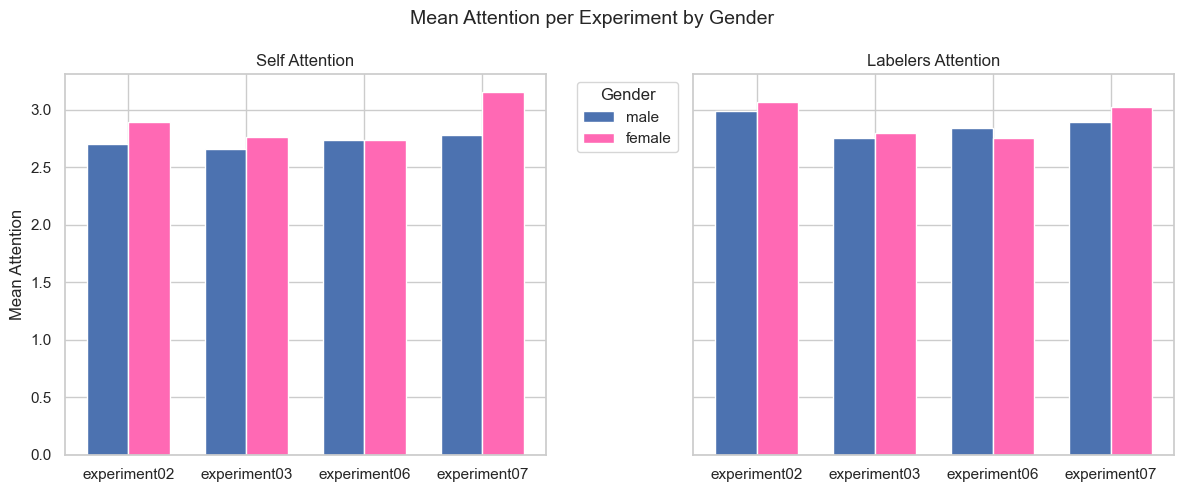

In [17]:
means = df.groupby(["experiment", "gender_name"])[[
    "labeler_mean_attention",
    "self_labeling attentionfilled"
]].mean().reset_index()

experiments = sorted(means["experiment"].unique())
genders = ["male", "female"]

x = np.arange(len(experiments))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(12,5), sharey=True)

colors = {
    "male": "#4C72B0",   # blue
    "female": "#FF69B4"  # pink
}

# left: Self Attention

ax = axes[0]

for i, gender in enumerate(genders):
    subset = means[means["gender_name"] == gender]
    subset = subset.set_index("experiment").reindex(experiments)

    ax.bar(
        x + (i - 0.5) * width,
        subset["self_labeling attentionfilled"],
        width,
        label=gender,
        color=colors[gender]
    )

ax.set_title("Self Attention")
ax.set_xticks(x)
ax.set_xticklabels(experiments)
ax.set_ylabel("Mean Attention")
axes[0].legend(title="Gender", bbox_to_anchor=(1.05, 1), loc="upper left")

# right: labelers Attention
ax = axes[1]

for i, gender in enumerate(genders):
    subset = means[means["gender_name"] == gender]
    subset = subset.set_index("experiment").reindex(experiments)

    ax.bar(
        x + (i - 0.5) * width,
        subset["labeler_mean_attention"],
        width,
        label=gender,
        color=colors[gender]
    )

ax.set_title("Labelers Attention")
ax.set_xticks(x)
ax.set_xticklabels(experiments)

plt.suptitle("Mean Attention per Experiment by Gender", fontsize=14)
plt.tight_layout()
plt.show()

Across experiments 2, 3 and 5, female participants consistently report slightly higher self-attention than males, with the difference being most pronounced in experiment05. This pattern is also reflected in the labelers’ assessments, where females are again rated marginally higher than males, though the gap is generally smaller compared to self-reports. Overall, both self and external evaluations follow similar trends across experimental conditions, suggesting that engagement differences are relatively stable, with only minor gender-based variation.

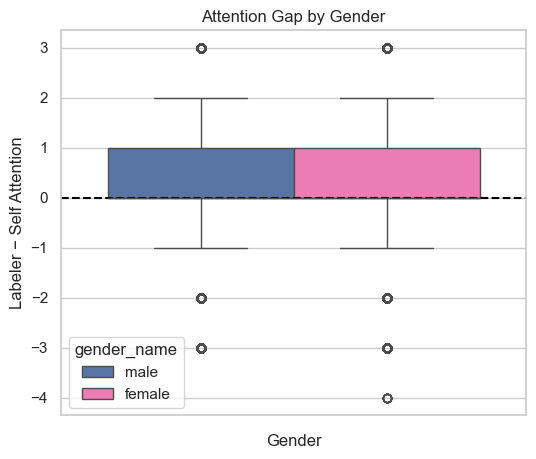

In [18]:
df["attention_gap"] = df["labeler_mean_attention"] - df["self_labeling attentionfilled"]

plt.figure(figsize=(6,5))

sns.boxplot(
    data=df,
    hue="gender_name",
    y="attention_gap",
    palette={"male": "#4C72B0", "female": "#FF69B4"}
)

plt.axhline(0, linestyle="--", color="black")
plt.title("Attention Gap by Gender")
plt.ylabel("Labeler − Self Attention")
plt.xlabel("Gender")

plt.show()

The attention gap distributions for male and female participants are largely centered around zero, indicating overall agreement between annotator and self-reported attention. However, female participants exhibit slightly greater variability, including more negative outliers, suggesting occasional underestimation of their engagement. In contrast, male ratings appear more tightly clustered.

## Heart Rate

In [34]:
df = df.sort_values(['group', 'experiment', 'subject', 'time'])

df['start_time'] = df.groupby(['group', 'experiment', 'subject'])['time'].transform('min')

df['relative_time_sec'] = (df['time'] - df['start_time']).dt.total_seconds()

In [48]:
bins = np.arange(0, 301, 1)  # 0 to 500 seconds
df['time_bin'] = pd.cut(
    df['relative_time_sec'],
    bins=bins,
    labels=bins[:-1],   # label each bin by its start (0,1,2,...)
    include_lowest=True
).astype(float)

In [49]:
df_subj = (
    df.groupby(['subject', 'experiment', 'gender_name', 'time_bin'])
    ['samsung_hr_none_wakeup_sensor_value']
    .mean()
    .reset_index()
) # first this groupby otherwise a subject with more rows in some frames contributes more for no reason

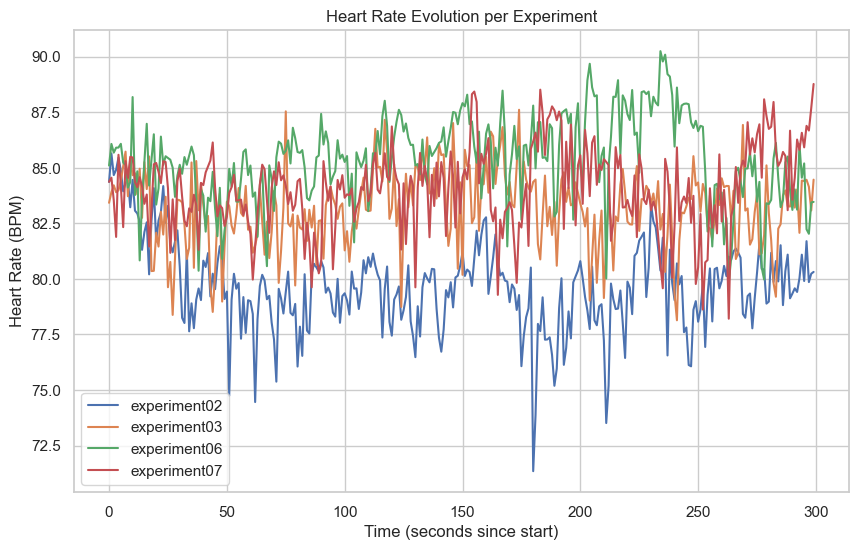

In [71]:
df_exp = (
    df_subj.groupby(['experiment', 'time_bin'])
    ['samsung_hr_none_wakeup_sensor_value']
    .mean()
    .reset_index())

plt.figure(figsize=(10,6))

for exp in df_exp['experiment'].unique():
    subset = df_exp[df_exp['experiment'] == exp]
    plt.plot(subset['time_bin'], subset['samsung_hr_none_wakeup_sensor_value'],
             label=exp)

plt.xlabel("Time (seconds since start)")
plt.ylabel("Heart Rate (BPM)")
plt.title("Heart Rate Evolution per Experiment")
plt.legend()
plt.show()

In [73]:
df_exp_gen = (
    df_subj.groupby(['experiment', 'gender_name', 'time_bin'])
    ['samsung_hr_none_wakeup_sensor_value']
    .mean()
    .reset_index())

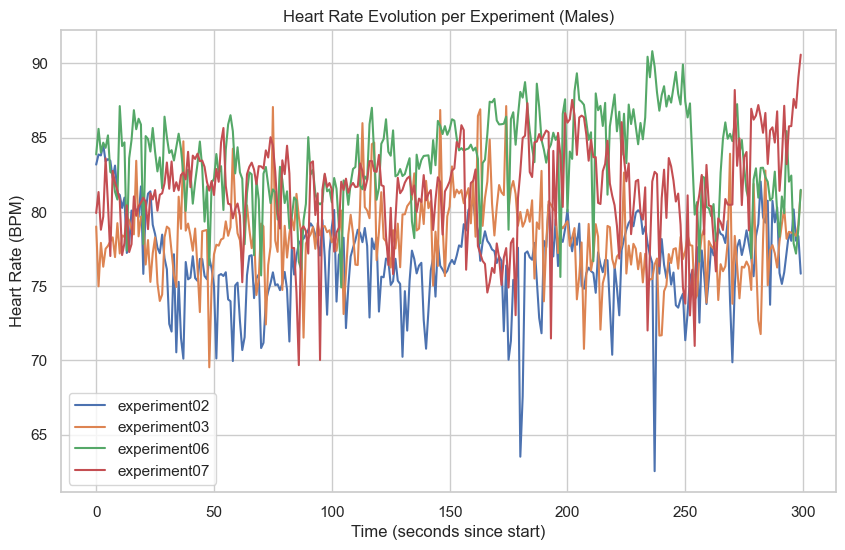

In [74]:
df_male = df_exp_gen[df_exp_gen['gender_name'] == 'male']

plt.figure(figsize=(10,6))

for exp in df_male['experiment'].unique():
    subset = df_male[df_male['experiment'] == exp]
    plt.plot(subset['time_bin'], subset['samsung_hr_none_wakeup_sensor_value'],
             label=exp)

plt.xlabel("Time (seconds since start)")
plt.ylabel("Heart Rate (BPM)")
plt.title("Heart Rate Evolution per Experiment (Males)")
plt.legend()
plt.show()

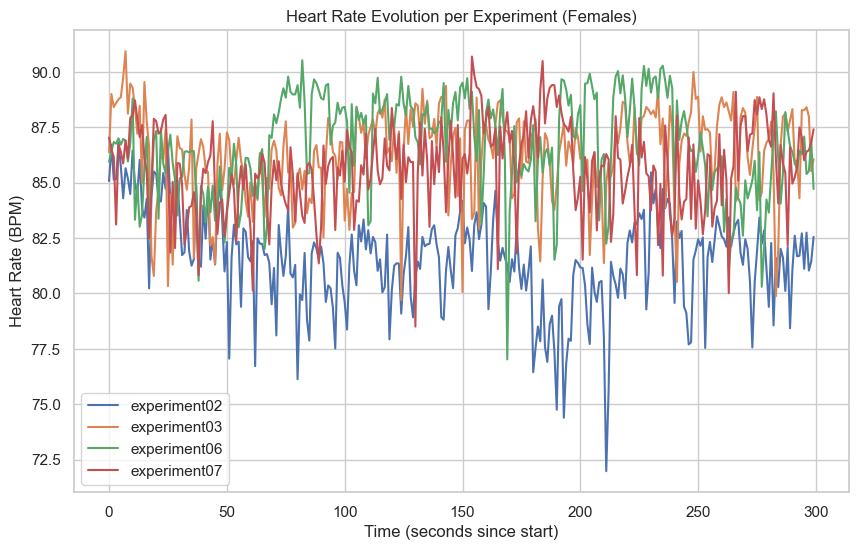

In [75]:
df_female = df_exp_gen[df_exp_gen['gender_name'] == 'female']

plt.figure(figsize=(10,6))

for exp in df_female['experiment'].unique():
    subset = df_female[df_female['experiment'] == exp]
    plt.plot(subset['time_bin'], subset['samsung_hr_none_wakeup_sensor_value'],
             label=exp)

plt.xlabel("Time (seconds since start)")
plt.ylabel("Heart Rate (BPM)")
plt.title("Heart Rate Evolution per Experiment (Females)")
plt.legend()
plt.show()

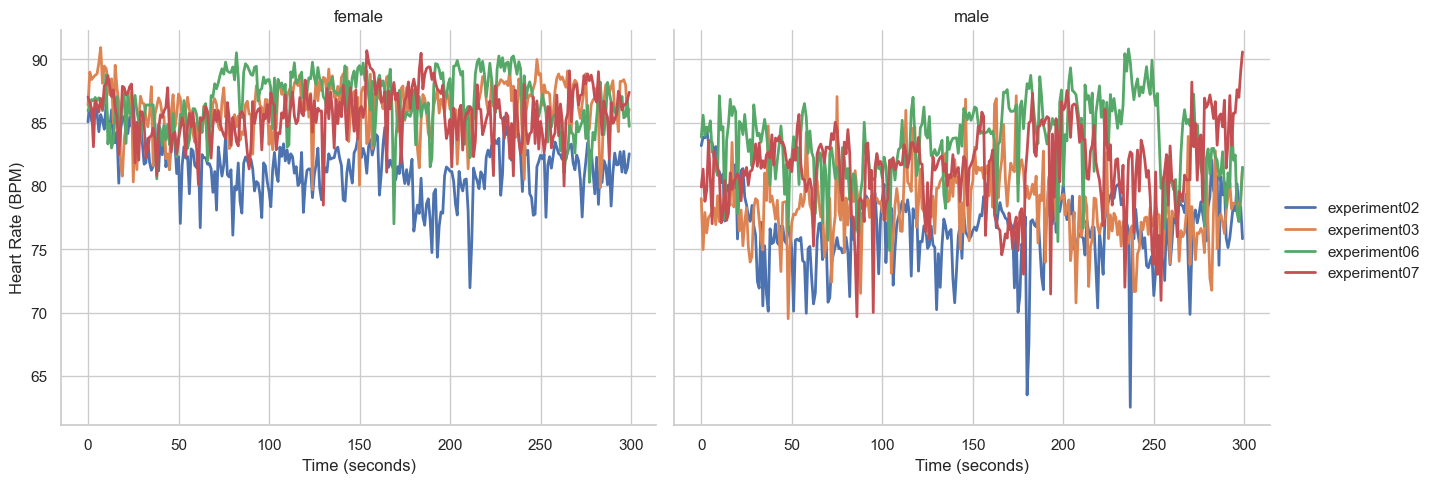

In [64]:
import seaborn as sns

g = sns.FacetGrid(df_exp, col="gender_name", height=5, aspect=1.3)

g.map_dataframe(
    sns.lineplot,
    x='time_bin',
    y='samsung_hr_none_wakeup_sensor_value',
    hue='experiment',
    linewidth=2
)

g.add_legend()
g.set_axis_labels("Time (seconds)", "Heart Rate (BPM)")
g.set_titles("{col_name}")

<Axes: xlabel='time_bin', ylabel='samsung_hr_none_wakeup_sensor_value'>

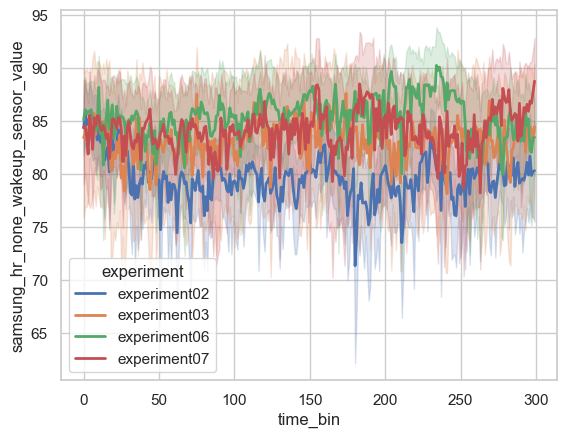

In [65]:
sns.lineplot(
    data=df_subj,
    x='time_bin',
    y='samsung_hr_none_wakeup_sensor_value',
    hue='experiment',
    errorbar='ci',
    linewidth=2
)

Text(0, 0.5, 'HR Difference (Male - Female)')

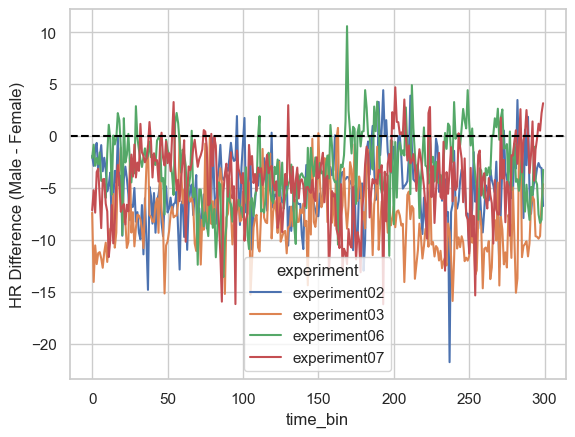

In [66]:
df_pivot = df_exp.pivot_table(
    index=['experiment', 'time_bin'],
    columns='gender_name',
    values='samsung_hr_none_wakeup_sensor_value'
).reset_index()

df_pivot['diff'] = df_pivot['male'] - df_pivot['female']

sns.lineplot(
    data=df_pivot,
    x='time_bin',
    y='diff',
    hue='experiment'
)

plt.axhline(0, linestyle='--', color='black')
plt.ylabel("HR Difference (Male - Female)")

attention levels through time? also per gender

<Axes: xlabel='gender_name', ylabel='samsung_hr_none_wakeup_sensor_value'>

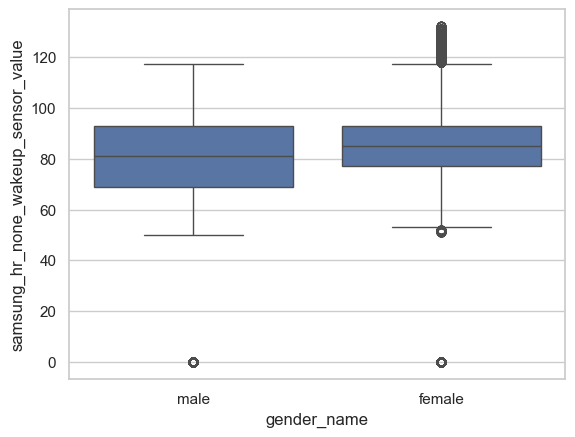

In [67]:
sns.boxplot(data=df, x='gender_name', y='samsung_hr_none_wakeup_sensor_value')

<Axes: xlabel='gender_name', ylabel='opt3007_light_mean'>

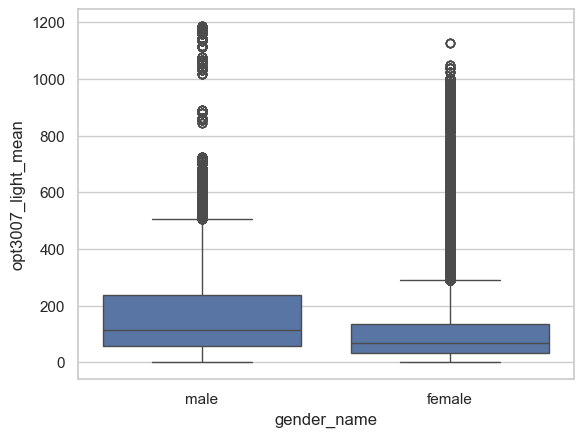

In [68]:
sns.boxplot(data=df, x='gender_name', y='opt3007_light_mean')

## Age Group

In [97]:
df["age_group"] = pd.cut(df["age"], bins=[18, 20, 22, 26, 30])
df['age_group'].value_counts(normalize=True)

age_group
(20, 22]    0.390746
(22, 26]    0.288116
(18, 20]    0.212211
(26, 30]    0.108927
Name: proportion, dtype: float64

C:\Users\cfrag\AppData\Local\Temp\ipykernel_33600\2231717626.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_means = df.groupby("age_group")[[


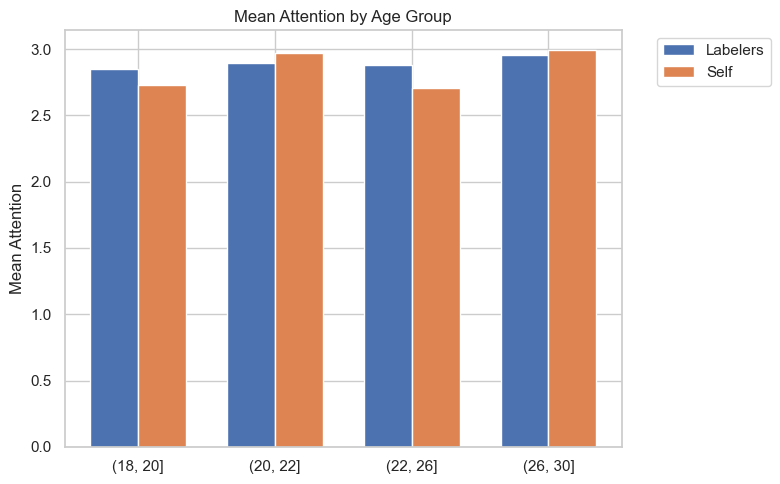

In [43]:
age_means = df.groupby("age_group")[[
    "labeler_mean_attention",
    "self_labeling attentionfilled"
]].mean()

# Ensure correct order
age_means = age_means.sort_index()

x = np.arange(len(age_means.index))
width = 0.35

plt.figure(figsize=(8,5))

plt.bar(
    x - width/2,
    age_means["labeler_mean_attention"],
    width,
    label="Labelers",
)

plt.bar(
    x + width/2,
    age_means["self_labeling attentionfilled"],
    width,
    label="Self",
)

plt.xticks(x, age_means.index)
plt.ylabel("Mean Attention")
plt.title("Mean Attention by Age Group")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()

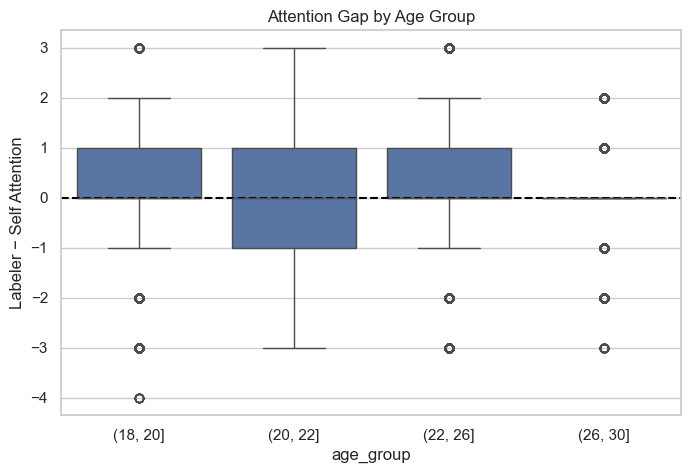

In [44]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="age_group",
    y="attention_gap"
)

plt.axhline(0, linestyle="--", color="black")
plt.title("Attention Gap by Age Group")
plt.ylabel("Labeler − Self Attention")

plt.show()

C:\Users\cfrag\AppData\Local\Temp\ipykernel_27980\1811089627.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_unique.groupby(["group", "age_group"])


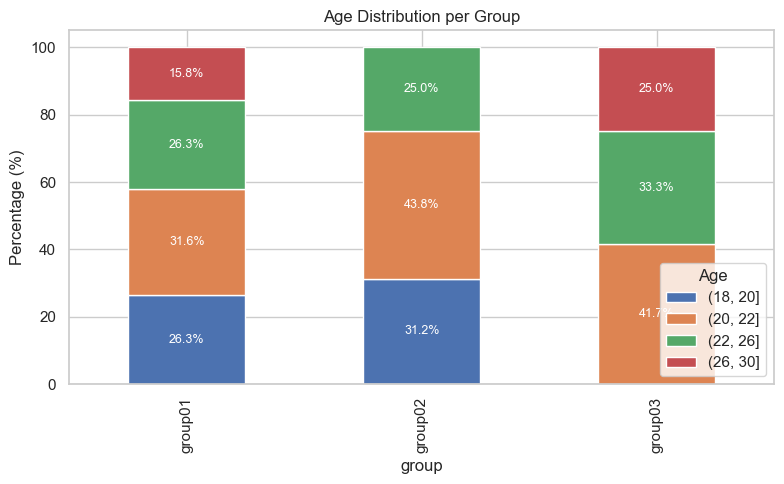

In [98]:
df_unique = df.drop_duplicates(subset=["group", "subject"])

age_dist = (
    df_unique.groupby(["group", "age_group"])
    .size()
    .unstack(fill_value=0)
)

age_pct = age_dist.div(age_dist.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(8,5))

age_pct.plot(
    kind="bar",
    stacked=True,
    ax=ax,
)

ax.set_ylabel("Percentage (%)")
ax.set_title("Age Distribution per Group")
ax.legend(title="Age")

for i, group in enumerate(age_pct.index):
    cumulative = 0
    for gender in age_pct.columns:
        value = age_pct.loc[group, gender]
        if value > 5:
            ax.text(
                i,
                cumulative + value / 2,
                f"{value:.1f}%",
                ha="center",
                va="center",
                color="white",
                fontsize=9
            )
        cumulative += value

plt.tight_layout()
plt.show()

In [99]:
df_unique

,group,time,subject,experiment,image_path,metadata,labeler_02 emotion,labeler_02 attention,labeler_01 attention,labeler_04 attention,...,opt3007_light_std,samsung_hr_none_wakeup_sensor_value,gender_name,age,race,labeler_mean_attention,attention_diff,id,subject_id,age_group
0,group01,10:59:49.000776,subject_01,experiment02,/gpfs/work5/0/prjs2039/DIPSER/group01/experime...,/gpfs/work5/0/prjs2039/DIPSER/group01/experime...,9.0,3.0,2.0,3.0,...,0.000000,94.0,male,27.0,white,2.75,0.25,group01_experiment02_subject_01,group01_subject_01,"(26.0, 30.0]"
2311,group01,10:59:49.017350,subject_02,experiment02,/gpfs/work5/0/prjs2039/DIPSER/group01/experime...,/gpfs/work5/0/prjs2039/DIPSER/group01/experime...,9.0,3.0,2.0,2.0,...,32.071171,81.0,female,21.0,white,2.25,-0.25,group01_experiment02_subject_02,group01_subject_02,"(20.0, 22.0]"
4600,group01,10:59:49.033494,subject_03,experiment02,/gpfs/work5/0/prjs2039/DIPSER/group01/experime...,/gpfs/work5/0/prjs2039/DIPSER/group01/experime...,9.0,3.0,2.0,2.0,...,6.939741,102.0,male,25.0,white,2.25,-0.25,group01_experiment02_subject_03,group01_subject_03,"(22.0, 26.0]"
6899,group01,10:59:49.014665,subject_04,experiment02,/gpfs/work5/0/prjs2039/DIPSER/group01/experime...,/gpfs/work5/0/prjs2039/DIPSER/group01/experime...,8.0,2.0,2.0,2.0,...,12.441865,77.0,male,24.0,white,2.00,0.00,group01_experiment02_subject_04,group01_subject_04,"(22.0, 26.0]"
9220,group01,10:59:49.014240,subject_05,experiment02,/gpfs/work5/0/prjs2039/DIPSER/group01/experime...,/gpfs/work5/0/prjs2039/DIPSER/group01/experime...,9.0,3.0,4.0,3.0,...,2.449490,78.0,female,23.0,white,3.00,-2.00,group01_experiment02_subject_05,group01_subject_05,"(22.0, 26.0]"
11560,group01,10:59:49.020458,subject_06,experiment02,/gpfs/work5/0/prjs2039/DIPSER/group01/experime...,/gpfs/work5/0/prjs2039/DIPSER/group01/experime...,7.0,3.0,3.0,3.0,...,2.400000,95.0,female,21.0,white,3.00,-1.00,group01_experiment02_subject_06,group01_subject_06,"(20.0, 22.0]"
13900,group01,10:59:49.004968,subject_07,experiment02,/gpfs/work5/0/prjs2039/DIPSER/group01/experime...,/gpfs/work5/0/prjs2039/DIPSER/group01/experime...,7.0,3.0,3.0,3.0,...,2.494438,74.0,male,26.0,white,3.00,1.00,group01_experiment02_subject_07,group01_subject_07,"(22.0, 26.0]"
16242,group01,10:59:49.022116,subject_08,experiment02,/gpfs/work5/0/prjs2039/DIPSER/group01/experime...,/gpfs/work5/0/prjs2039/DIPSER/group01/experime...,9.0,2.0,2.0,2.0,...,2.939388,76.0,male,27.0,white,2.00,0.00,group01_experiment02_subject_08,group01_subject_08,"(26.0, 30.0]"
18573,group01,10:59:49.008756,subject_09,experiment02,/gpfs/work5/0/prjs2039/DIPSER/group01/experime...,/gpfs/work5/0/prjs2039/DIPSER/group01/experime...,7.0,2.0,4.0,4.0,...,14.330387,72.0,male,31.0,white,3.25,-1.25,group01_experiment02_subject_09,group01_subject_09,NaN
20771,group01,10:59:49.008949,subject_10,experiment02,/gpfs/work5/0/prjs2039/DIPSER/group01/experime...,/gpfs/work5/0/prjs2039/DIPSER/group01/experime...,7.0,4.0,5.0,3.0,...,168.366980,73.0,female,21.0,white,4.25,-2.25,group01_experiment02_subject_10,group01_subject_10,"(20.0, 22.0]"


In [103]:
age = (
    df_unique.groupby(['age_group', 'group'])
    .size()
    .unstack(fill_value=0)
)
age

C:\Users\cfrag\AppData\Local\Temp\ipykernel_27980\1094296640.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_unique.groupby(['age_group', 'group'])


group,group01,group02,group03
age_group,,,
"(18, 20]",5,5,0
"(20, 22]",6,7,5
"(22, 26]",5,4,4
"(26, 30]",3,0,3


# RACE

In [37]:
df.groupby(['gender_name','race'])['attention_gap'].mean().reset_index()

,gender_name,race,attention_gap
0,female,asian,0.278340
1,female,latino_hispanic,0.190992
2,female,white,0.013085
3,male,white,0.149333


In [46]:
gender_race = (
    df_unique.groupby(["race", "gender_name"])
    .size()
    .unstack(fill_value=0)
)
gender_race

gender_name,female,male
race,,
asian,1,0
latino_hispanic,2,0
white,36,18


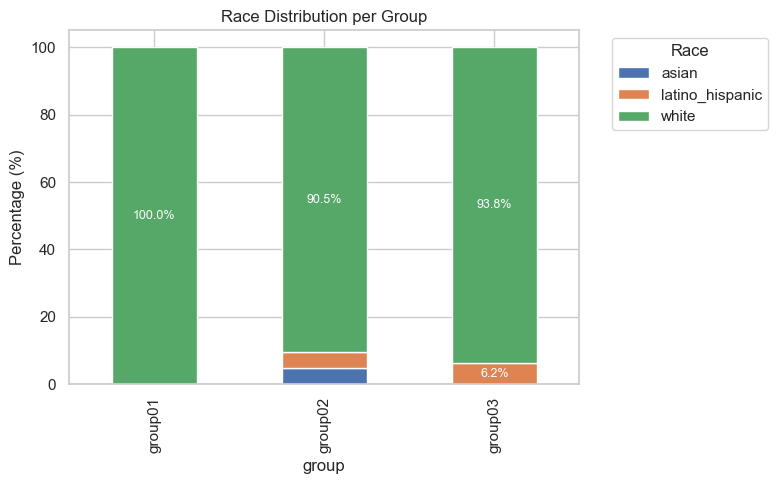

In [39]:
race_dist = (
    df_unique.groupby(["group", "race"])
    .size()
    .unstack(fill_value=0)
)

race_pct = race_dist.div(race_dist.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(8,5))

race_pct.plot(
    kind="bar",
    stacked=True,
    ax=ax,
)

ax.set_ylabel("Percentage (%)")
ax.set_title("Race Distribution per Group")
ax.legend(title="Race", bbox_to_anchor=(1.05, 1), loc="upper left")

for i, group in enumerate(race_pct.index):
    cumulative = 0
    for gender in race_pct.columns:
        value = race_pct.loc[group, gender]
        if value > 5:
            ax.text(
                i,
                cumulative + value / 2,
                f"{value:.1f}%",
                ha="center",
                va="center",
                color="white",
                fontsize=9
            )
        cumulative += value

plt.tight_layout()
plt.show()

In [40]:
df_unique['race'].value_counts()

race
white              54
latino_hispanic     2
asian               1
Name: count, dtype: int64

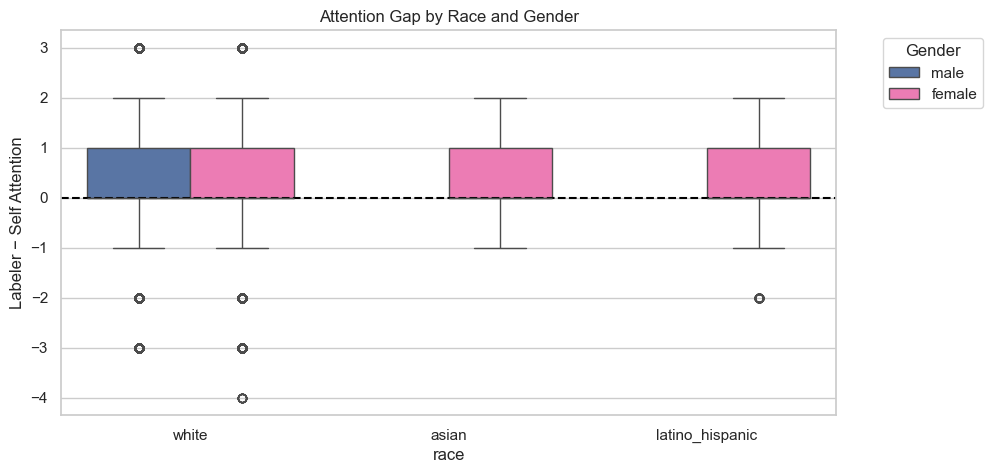

In [19]:
plt.figure(figsize=(10,5))

sns.boxplot(
    data=df,
    x="race",
    y="attention_gap",
    hue="gender_name",
    palette={"male": "#4C72B0", "female": "#FF69B4"}
)

plt.legend(title="Gender", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.axhline(0, linestyle="--", color="black")
plt.xticks(rotation=0)
plt.title("Attention Gap by Race and Gender")
plt.ylabel("Labeler − Self Attention")

plt.show()

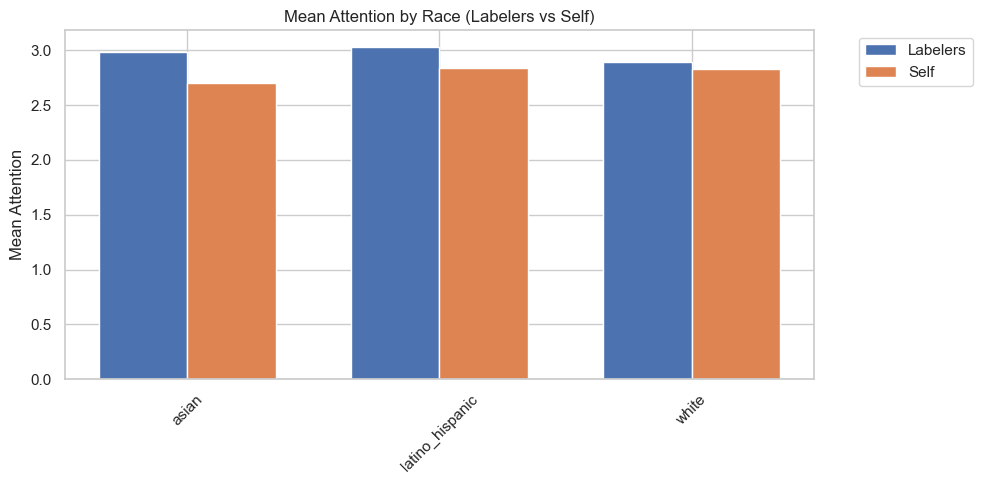

In [41]:
race_means = df.groupby("race")[[
    "labeler_mean_attention",
    "self_labeling attentionfilled"
]].mean()

x = np.arange(len(race_means.index))
width = 0.35

plt.figure(figsize=(10,5))

plt.bar(x - width/2, race_means["labeler_mean_attention"], width, label="Labelers")
plt.bar(x + width/2, race_means["self_labeling attentionfilled"], width, label="Self")

plt.xticks(x, race_means.index, rotation=45)
plt.ylabel("Mean Attention")
plt.title("Mean Attention by Race (Labelers vs Self)")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()

The dataset is heavily dominated by White participants (29 female, 16 male), while other groups are sparsely represented (e.g., Asian: 2 female, 0 male; Middle Eastern: 2 female, 1 male). As a result, variability in smaller groups is likely driven by a few subjects, making the estimates less reliable.

There is a small but consistent gender difference within the White group, where annotators slightly underestimate female engagement relative to self-reports, while male engagement is rated closer to (or slightly above) self-perception.

For the White group, which is the most well-represented, labeler and self attention are closely aligned, indicating no substantial bias. The results of middle eastern and asian should not be interpreted as there are only 3 and 2 subjects on each group as shown in the table above.

Attention levels are relatively consistent across age groups, with both annotator and self-reported scores showing similar trends. Overall, differences across age groups are modest, indicating no strong age-based bias, though small systematic shifts in perception are observable.